# Comparing Emulator Backends for Comoving Angular Distance

This notebook trains all four emulator backends on the same data and compares
their accuracy, training time, prediction speed, and (where available) uncertainty.

| Backend | Class | Key trade-off |
|---------|-------|---------------|
| **Gaussian Process** | `GPEmulator` | Best accuracy at small N, provides uncertainty, O(N³) scaling |
| **TensorFlow** | `TensorFlowEmulator` | Scales to large N, fast batch prediction, no native uncertainty |
| **PyTorch** | `PyTorchEmulator` | Same as TF with more Pythonic API, no native uncertainty |
| **Symbolic (PySR)** | `SymbolicEmulator` | Discovers closed-form expression, inspectable, slow to train |

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

from tissage_cosmique.computations.distances import comoving_angular_distance
from tissage_cosmique.emulators import (
    GPEmulator,
    TensorFlowEmulator,
    PyTorchEmulator,
    SymbolicEmulator,
    build_training_data,
    params_to_feature_matrix,
    validate_emulator,
)

## 1. Generate shared training and test data

In [2]:
PARAM_NAMES = ["Omega_c", "h", "sigma8"]
FIXED_PARAMS = dict(Omega_b=0.0486, n_s=0.9667, Omega_k=0.0, w0=-1.0, wa=0.0)
a_grid = np.linspace(0.2, 0.8, 30)

rng = np.random.default_rng(42)
n_train, n_test = 50, 15

def make_samples(n, rng):
    return [
        {"Omega_c": rng.uniform(0.22, 0.32), "h": rng.uniform(0.62, 0.75),
         "sigma8": rng.uniform(0.77, 0.87), **FIXED_PARAMS}
        for _ in range(n)
    ]

train_samples = make_samples(n_train, rng)
test_samples = make_samples(n_test, rng)

X_train, y_train = build_training_data(comoving_angular_distance, train_samples, a_grid, PARAM_NAMES)
X_test, y_test = build_training_data(comoving_angular_distance, test_samples, a_grid, PARAM_NAMES)

print(f"Training: {X_train.shape[0]} points ({n_train} cosmologies x {len(a_grid)} scale factors)")
print(f"Test:     {X_test.shape[0]} points ({n_test} cosmologies x {len(a_grid)} scale factors)")

Training: 1500 points (50 cosmologies x 30 scale factors)
Test:     450 points (15 cosmologies x 30 scale factors)


## 2. Train all backends and collect timing

In [3]:
backends = {
    "GP": GPEmulator(feature_names=PARAM_NAMES + ["a"]),
    "TensorFlow": TensorFlowEmulator(
        feature_names=PARAM_NAMES + ["a"], hidden_layers=[64, 64], n_epochs=500,
    ),
    "PyTorch": PyTorchEmulator(
        feature_names=PARAM_NAMES + ["a"], hidden_layers=[64, 64], n_epochs=500,
    ),
}

# PySR requires Julia and can be slow — include it if available
try:
    import pysr as _pysr  # noqa: F401
    backends["PySR"] = SymbolicEmulator(
        feature_names=PARAM_NAMES + ["a"], niterations=10, maxsize=20,
    )
except ImportError:
    print("PySR not available — skipping symbolic backend")

train_times = {}
for name, emu in backends.items():
    print(f"Training {name}...", end=" ", flush=True)
    t0 = time.time()
    emu.fit(X_train, y_train)
    elapsed = time.time() - t0
    train_times[name] = elapsed
    print(f"{elapsed:.1f}s")

colors = {"GP": "tab:blue", "TensorFlow": "tab:orange", "PyTorch": "tab:green", "PySR": "tab:red"}
styles = {"GP": "--", "TensorFlow": "-.", "PyTorch": ":", "PySR": "--"}

Training GP... 

9.5s
Training TensorFlow... 

26.1s
Training PyTorch... 

9.9s
Training PySR... 

12.0s


## 3. Validate all backends on the same test set

In [4]:
results = {}
predict_times = {}

for name, emu in backends.items():
    t0 = time.time()
    res = validate_emulator(emu, X_test, y_test)
    predict_times[name] = time.time() - t0
    results[name] = res

# Summary table
header = f"{'Backend':<14} {'R²':>10} {'MAE (Mpc)':>10} {'RMSE (Mpc)':>11} {'Max Rel Err':>12} {'Train (s)':>10} {'Pred (ms)':>10}"
print(header)
print("-" * len(header))
for name in backends:
    r = results[name]
    print(
        f"{name:<14} {r.r2_score:>10.6f} {r.mae:>10.2f} {r.rmse:>11.2f}"
        f" {r.max_relative_error:>11.4%} {train_times[name]:>10.1f} {predict_times[name]*1000:>10.1f}"
    )

Backend                R²  MAE (Mpc)  RMSE (Mpc)  Max Rel Err  Train (s)  Pred (ms)
-----------------------------------------------------------------------------------
GP               1.000000       0.42        0.54     0.1174%        9.5        8.1
TensorFlow       0.999417      34.53       44.58     9.1276%       26.1       72.6
PyTorch          0.999621      25.11       35.93     7.2172%        9.9        0.5
PySR             0.995908      88.50      118.09    34.7898%       12.0       13.0


## 4. Visual comparison: predictions for one test cosmology

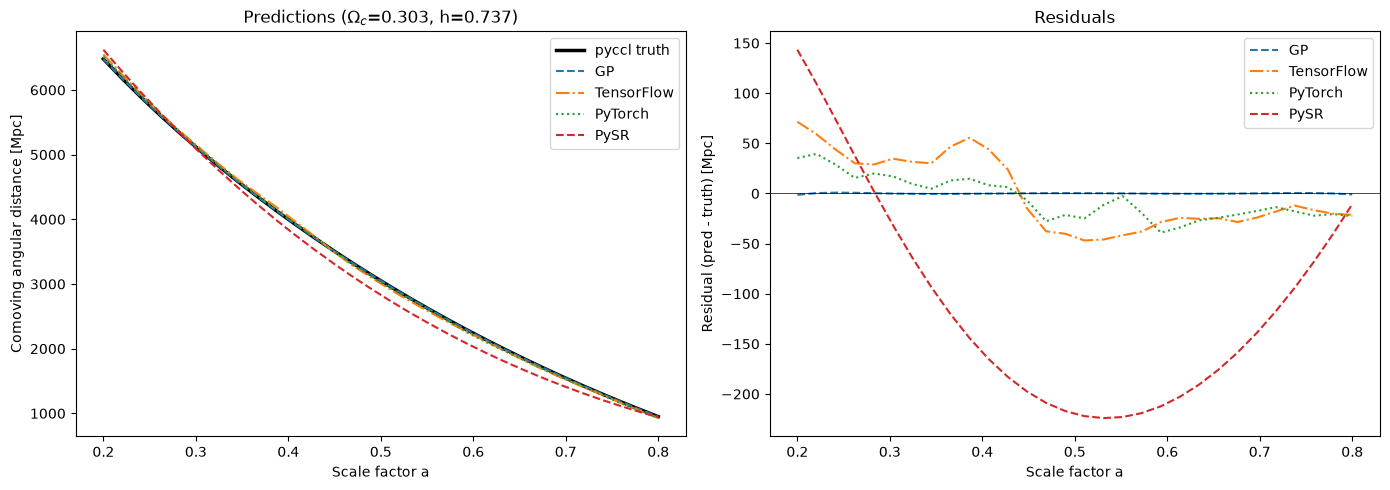

In [5]:
test_params = test_samples[0]
truth = comoving_angular_distance(test_params, a_grid)
X_pred = params_to_feature_matrix(test_params, a_grid, PARAM_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predictions
ax = axes[0]
ax.plot(a_grid, truth, "k-", lw=2.5, label="pyccl truth")
for name, emu in backends.items():
    pred = emu.predict(X_pred)
    ax.plot(a_grid, pred, styles[name], color=colors[name], lw=1.5, label=name)
ax.set_xlabel("Scale factor a")
ax.set_ylabel("Comoving angular distance [Mpc]")
ax.set_title(f"Predictions ($\\Omega_c$={test_params['Omega_c']:.3f}, h={test_params['h']:.3f})")
ax.legend()

# Right: residuals
ax = axes[1]
for name, emu in backends.items():
    pred = emu.predict(X_pred)
    residual = pred - truth
    ax.plot(a_grid, residual, styles[name], color=colors[name], lw=1.5, label=name)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Scale factor a")
ax.set_ylabel("Residual (pred - truth) [Mpc]")
ax.set_title("Residuals")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Relative error comparison across all test cosmologies

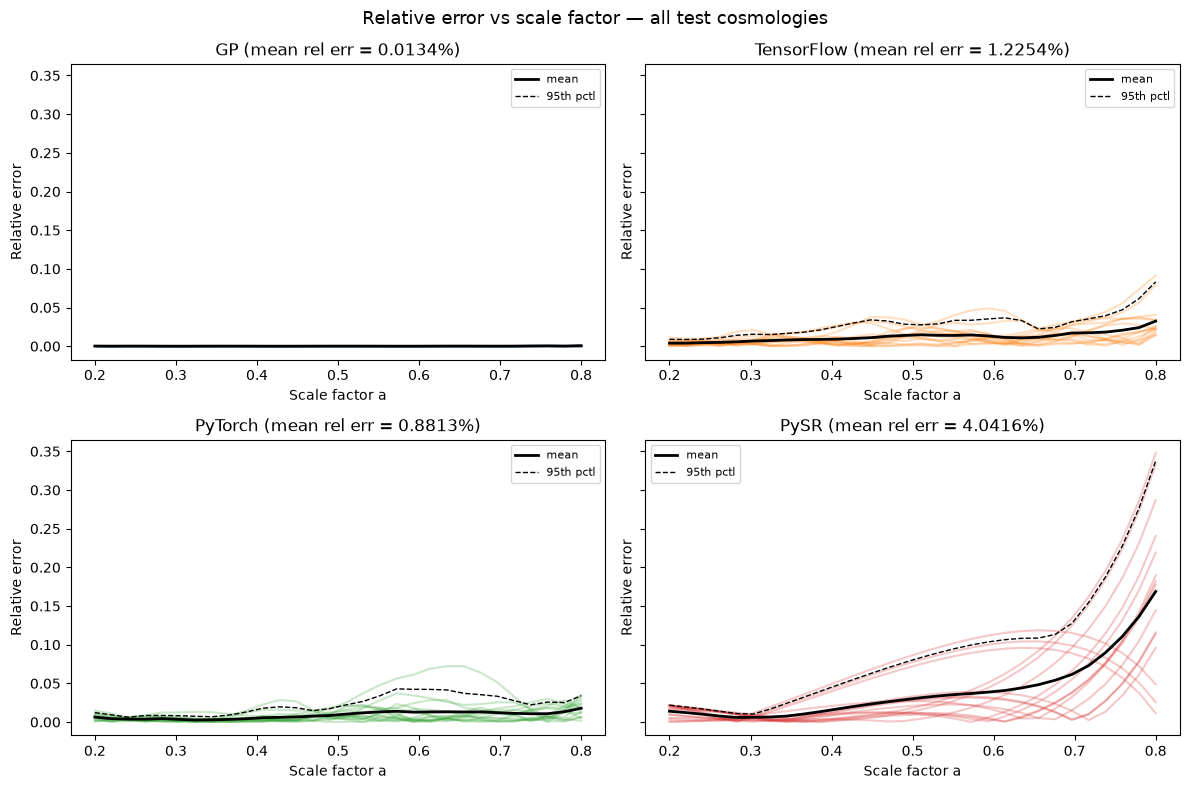

In [6]:
n_backends = len(backends)
ncols = min(n_backends, 2)
nrows = (n_backends + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True, squeeze=False)

for idx, (name, emu) in enumerate(backends.items()):
    ax = axes[idx // ncols, idx % ncols]
    y_pred = emu.predict(X_test)
    rel_err = np.abs(y_pred - y_test) / np.maximum(np.abs(y_test), 1.0)
    rel_err_by_a = rel_err.reshape(n_test, len(a_grid))

    ax.plot(a_grid, rel_err_by_a.T, alpha=0.25, color=colors[name])
    ax.plot(a_grid, np.mean(rel_err_by_a, axis=0), "k-", lw=2, label="mean")
    ax.plot(a_grid, np.percentile(rel_err_by_a, 95, axis=0), "k--", lw=1, label="95th pctl")
    ax.set_xlabel("Scale factor a")
    ax.set_ylabel("Relative error")
    r = results[name]
    ax.set_title(f"{name} (mean rel err = {r.mean_relative_error:.4%})")
    ax.legend(fontsize=8)

# Hide unused axes
for idx in range(n_backends, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle("Relative error vs scale factor — all test cosmologies", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Residual distributions

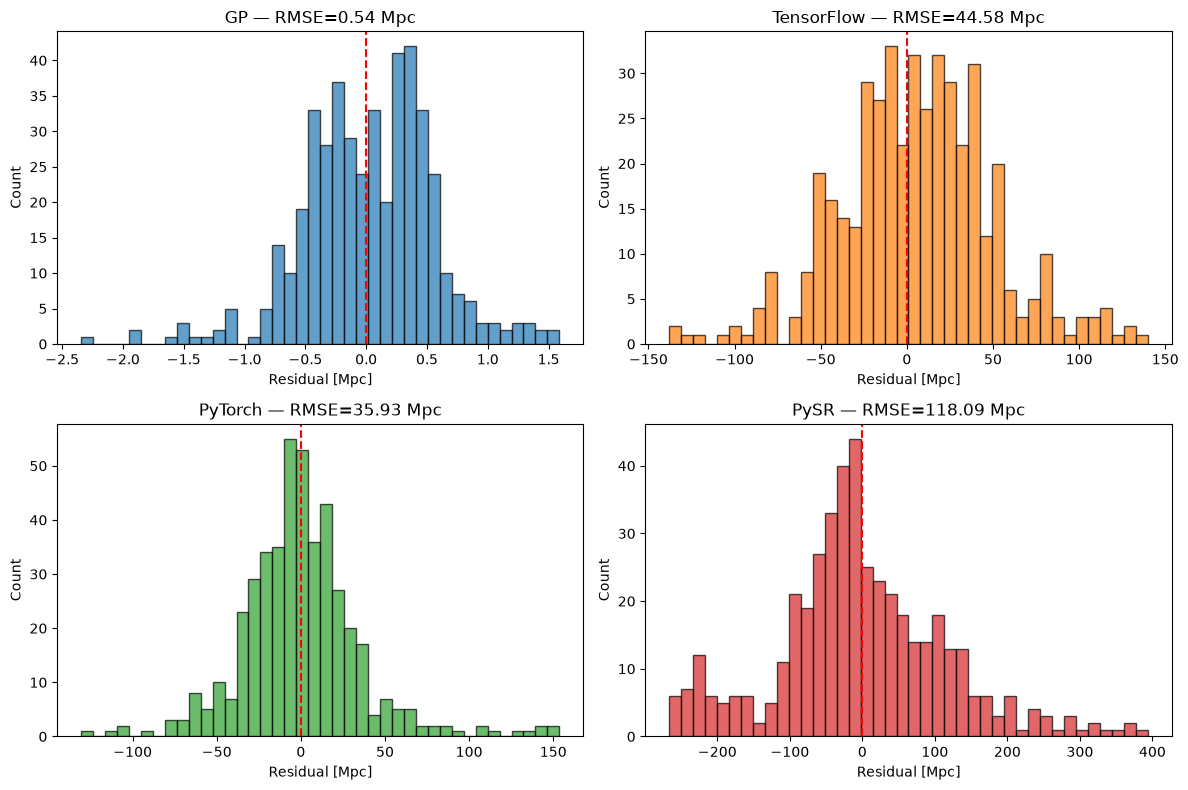

In [7]:
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

for idx, (name, _) in enumerate(backends.items()):
    ax = axes[idx // ncols, idx % ncols]
    r = results[name]
    ax.hist(r.residuals, bins=40, edgecolor="black", alpha=0.7, color=colors[name])
    ax.axvline(0, color="red", linestyle="--")
    ax.set_xlabel("Residual [Mpc]")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} — RMSE={r.rmse:.2f} Mpc")

for idx in range(n_backends, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Training time vs accuracy

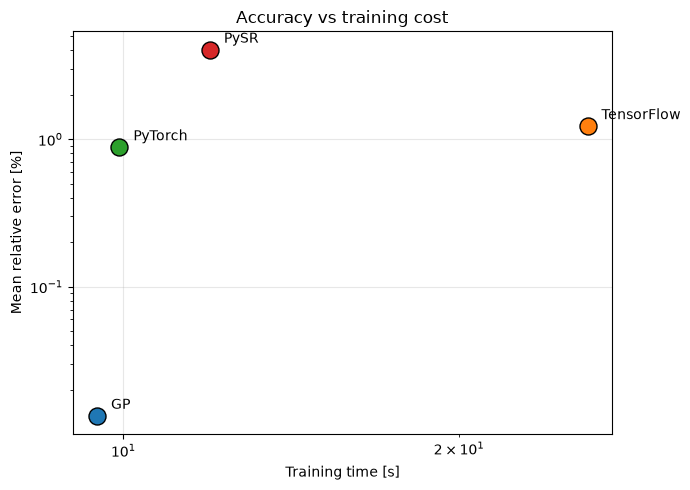

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

for name in backends:
    r = results[name]
    ax.scatter(
        train_times[name], r.mean_relative_error * 100,
        s=150, color=colors[name], zorder=5, edgecolors="black",
    )
    ax.annotate(
        name, (train_times[name], r.mean_relative_error * 100),
        textcoords="offset points", xytext=(10, 5), fontsize=10,
    )

ax.set_xlabel("Training time [s]")
ax.set_ylabel("Mean relative error [%]")
ax.set_title("Accuracy vs training cost")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. GP uncertainty vs actual errors

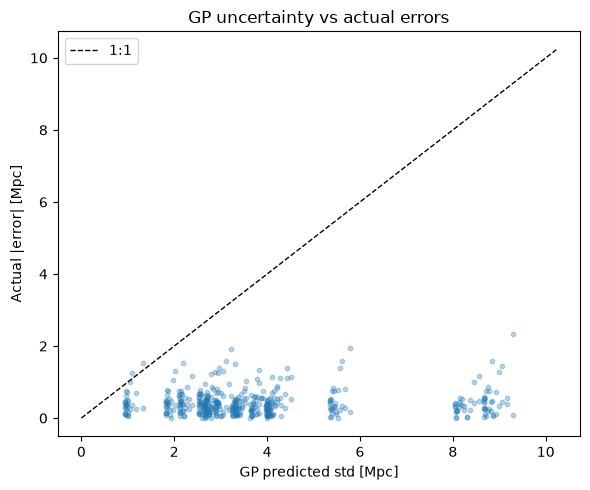

In [9]:
gp = backends["GP"]
mean, std = gp.predict_with_std(X_test)
abs_err = np.abs(mean - y_test)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(std, abs_err, alpha=0.3, s=10, color="tab:blue")
lims = [0, max(std.max(), abs_err.max()) * 1.1]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("GP predicted std [Mpc]")
ax.set_ylabel("Actual |error| [Mpc]")
ax.set_title("GP uncertainty vs actual errors")
ax.legend()
plt.tight_layout()
plt.show()

## 9. PySR: the discovered expression

In [10]:
if "PySR" in backends:
    pysr_emu = backends["PySR"]
    meta = pysr_emu.metadata
    print(f"Best expression: {meta['best_expression']}")
    print(f"\nThis closed-form formula can be evaluated with pure numpy — no ML runtime needed.")
else:
    print("PySR was not included in this run. Install pysr and re-run to see the discovered expression.")

Best expression: Omega_c + (h - (-Omega_c - h + (a - 7.5734587)**2))**2

This closed-form formula can be evaluated with pure numpy — no ML runtime needed.


## Summary

**GP** gives the best accuracy for this small training set (50 cosmologies) and is the
only backend with native uncertainty estimates. The trade-off is O(N³) training cost,
which becomes prohibitive above ~5000 training points.

**TensorFlow and PyTorch** neural networks achieve good accuracy with 500 training
epochs. Their strength is scalability — they handle much larger training sets and
higher-dimensional outputs without the cubic cost. Accuracy improves with more
training data and epochs.

**PySR** discovers a compact mathematical formula. Accuracy depends on the complexity
budget (`maxsize`) and search iterations. The resulting expression is inspectable,
has zero runtime dependencies, and evaluates in nanoseconds — ideal for inner loops
where even GP/NN overhead matters.

Choose based on your constraints:
- Small N, need uncertainty → **GP**
- Large N, high-dimensional output → **TensorFlow / PyTorch**
- Need a formula you can inspect or embed → **PySR**